# Laboratorio: Transformers — del token a la representación contextual
**Curso de Procesamiento de Lenguaje Natural**
Edwin Puertas, PhD

Notebook compañero de la presentación *W6b_Transformers_Topicos*. Cada sección sigue la secuencia del curso:
**Concepto → Predicción → Implementación → Experimento → Análisis crítico.**

| Sección | Tópico de la presentación | Requiere internet |
|---|---|---|
| 1. BPE desde cero | 02 | No |
| 2. Self-attention paso a paso | 04 | No |
| 3. Multi-head attention | 05 | No |
| 4. Codificación posicional | 03 | No |
| 5. Máscaras causal y de padding | 07 | No |
| 6. Bloque Transformer pre-norm y un mini-LM | 06, 08 | No |
| 7. Decodificación | 08 | No |
| 8. BETO: fill-mask y embeddings contextuales | 09, 10 | Sí (Hugging Face) |
| 9. LLM local: zero-shot y NER en JSON | 13, 15 | Sí (Hugging Face) |

**Regla del laboratorio:** antes de ejecutar cada celda marcada con ✍️, escriba su predicción (forma del tensor, valor esperado). Se evalúa la explicación, no solo que el código corra.

Referencia central: Jurafsky & Martin, *Speech and Language Processing* (v. 08/2026), caps. 2, 7, 8, 9 y 10.

In [1]:
# Si usa Colab o un entorno nuevo, descomente:
# !pip install -q torch transformers matplotlib numpy
import math, json, re, random
from collections import Counter
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
np.set_printoptions(precision=3, suppress=True)
print("torch", torch.__version__)

torch 2.14.1+cu130


## 1. BPE desde cero (tópico 02)
**Concepto.** BPE parte de caracteres y fusiona repetidamente el par adyacente más frecuente (Sennrich et al., 2016; J&M §2.4). Las fusiones no cruzan límites de palabra; usamos `_` como marca de fin de palabra.

✍️ **Predicción:** en un corpus con muchas palabras terminadas en *-ción* y *-mente*, ¿qué fusiones esperaría ver primero?

In [2]:
corpus = """la atención permite que cada palabra mire a las demás palabras
la representación de cada palabra depende del contexto
la información fluye rápidamente entre posiciones
la traducción automática mejoró notablemente con la atención
el modelo aprende la segmentación y la normalización del texto
finalmente la generación de texto ocurre token a token"""

def palabras_a_simbolos(texto):
    freqs = Counter(texto.split())
    return {tuple(w) + ("_",): f for w, f in freqs.items()}

def contar_pares(vocab):
    pares = Counter()
    for simbolos, f in vocab.items():
        for a, b in zip(simbolos, simbolos[1:]):
            pares[(a, b)] += f
    return pares

def fusionar(par, vocab):
    nuevo = {}
    for simbolos, f in vocab.items():
        s, i = [], 0
        while i < len(simbolos):
            if i < len(simbolos) - 1 and (simbolos[i], simbolos[i + 1]) == par:
                s.append(simbolos[i] + simbolos[i + 1]); i += 2
            else:
                s.append(simbolos[i]); i += 1
        nuevo[tuple(s)] = f
    return nuevo

def entrenar_bpe(texto, k):
    vocab = palabras_a_simbolos(texto)
    merges = []
    for _ in range(k):
        pares = contar_pares(vocab)
        if not pares:
            break
        mejor = max(pares, key=pares.get)
        merges.append(mejor)
        vocab = fusionar(mejor, vocab)
    return merges, vocab

merges, vocab = entrenar_bpe(corpus, 40)
for i, m in enumerate(merges[:15], 1):
    print(f"{i:2d}. {m[0]!r} + {m[1]!r} -> {m[0] + m[1]!r}")

 1. 'a' + '_' -> 'a_'
 2. 'e' + 'n' -> 'en'
 3. 'e' + '_' -> 'e_'
 4. 'c' + 'i' -> 'ci'
 5. 'n' + '_' -> 'n_'
 6. 'l' + 'a_' -> 'la_'
 7. 'ci' + 'ó' -> 'ció'
 8. 'ció' + 'n_' -> 'ción_'
 9. 'en' + 't' -> 'ent'
10. 't' + 'o' -> 'to'
11. 'a' + 'l' -> 'al'
12. 'd' + 'e' -> 'de'
13. 'a' + 'ción_' -> 'ación_'
14. 'a' + 'b' -> 'ab'
15. 's' + '_' -> 's_'


In [3]:
def codificar(palabra, merges):
    simbolos = list(palabra) + ["_"]
    for a, b in merges:                       # mismo orden del entrenamiento
        i, s = 0, []
        while i < len(simbolos):
            if i < len(simbolos) - 1 and simbolos[i] == a and simbolos[i + 1] == b:
                s.append(a + b); i += 2
            else:
                s.append(simbolos[i]); i += 1
        simbolos = s
    return simbolos

for w in ["atención", "contextualización", "rápidamente", "transformador"]:
    print(f"{w:20s} -> {codificar(w, merges)}")

atención             -> ['atención_']
contextualización    -> ['c', 'o', 'n', 'tex', 't', 'u', 'al', 'i', 'z', 'ación_']
rápidamente          -> ['r', 'á', 'p', 'i', 'd', 'a', 'mente_']
transformador        -> ['t', 'r', 'a', 'n', 's', 'f', 'o', 'rm', 'ad', 'o', 'r', '_']


**Análisis crítico**
1. ¿Qué palabras nuevas (no vistas) quedan bien segmentadas y cuáles se fragmentan en caracteres? ¿Por qué?
2. Aumente `k` a 100 y a 10. ¿Qué pasa con la longitud promedio en tokens? Relacione con costo de cómputo y longitud de contexto.
3. Un tokenizador entrenado mayoritariamente en inglés, ¿qué haría con *contextualización*? (Petrov et al., 2023).

## 2. Self-attention paso a paso (tópico 04)
$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$
Reproducimos el ejemplo numérico de la presentación: «el banco cerró», $d=4$, $d_k=d_v=2$.

✍️ **Predicción:** ¿qué forma tienen $Q$, la matriz $\alpha$ y $Z$? ¿Cuánto suma cada fila de $\alpha$?

In [4]:
def softmax(S, axis=-1):
    S = S - S.max(axis=axis, keepdims=True)      # estabilidad numérica
    E = np.exp(S)
    return E / E.sum(axis=axis, keepdims=True)

def self_attention(X, WQ, WK, WV, mask=None):
    Q, K, V = X @ WQ, X @ WK, X @ WV
    S = Q @ K.T / np.sqrt(K.shape[-1])
    if mask is not None:
        S = S + mask
    A = softmax(S)
    return A @ V, A, (Q, K, V, S)

tokens = ["el", "banco", "cerró"]
X  = np.array([[1,0,1,0],[0,1,0,1],[1,1,0,0]], float)
WQ = np.array([[1,0],[0,1],[1,0],[0,1]], float)
WK = np.array([[1,0],[1,1],[0,1],[0,0]], float)
WV = np.array([[2,0],[0,1],[0,0],[0,1]], float)

Z, A, (Q, K, V, S) = self_attention(X, WQ, WK, WV)
print("Q =\n", Q, "\nK =\n", K, "\nV =\n", V)
print("Scores escalados S =\n", S)
print("Pesos α =\n", A, "\nsuma por fila:", A.sum(1))
print("Salida Z =\n", Z)

Q =
 [[2. 0.]
 [0. 2.]
 [1. 1.]] 
K =
 [[1. 1.]
 [1. 1.]
 [2. 1.]] 
V =
 [[2. 0.]
 [0. 2.]
 [2. 1.]]
Scores escalados S =
 [[1.414 1.414 2.828]
 [1.414 1.414 1.414]
 [1.414 1.414 2.121]]
Pesos α =
 [[0.164 0.164 0.673]
 [0.333 0.333 0.333]
 [0.248 0.248 0.503]] 
suma por fila: [1. 1. 1.]
Salida Z =
 [[1.673 1.   ]
 [1.333 1.   ]
 [1.503 1.   ]]


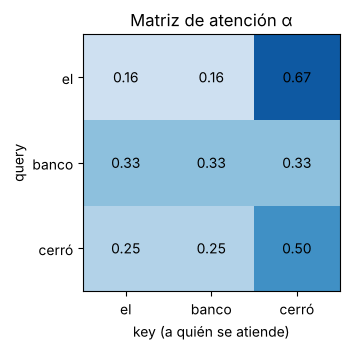

In [5]:
fig, ax = plt.subplots(figsize=(4, 3.6))
ax.imshow(A, cmap="Blues", vmin=0, vmax=0.8)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{A[i,j]:.2f}", ha="center", va="center")
ax.set_xticks(range(3), tokens); ax.set_yticks(range(3), tokens)
ax.set_xlabel("key (a quién se atiende)"); ax.set_ylabel("query")
ax.set_title("Matriz de atención α"); plt.tight_layout(); plt.show()

### ¿Por qué dividir por $\sqrt{d_k}$?
Si los componentes de $q$ y $k$ son independientes con media 0 y varianza 1, entonces $\mathrm{Var}(q\cdot k)=d_k$. Verifiquémoslo y veamos el efecto sobre el softmax.

In [6]:
for dk in [4, 64, 512]:
    q = np.random.randn(20000, dk); k = np.random.randn(20000, dk)
    dots = (q * k).sum(1)
    print(f"d_k={dk:4d}  Var(q·k)={dots.var():8.1f}   Var(q·k/√d_k)={(dots/np.sqrt(dk)).var():.2f}")

# Efecto sobre el softmax: 8 scores aleatorios con d_k = 512
dk = 512
qk = np.random.randn(8, dk) @ np.random.randn(dk)
print("\nsin escalar :", softmax(qk).round(3))
print("escalado    :", softmax(qk / np.sqrt(dk)).round(3))

d_k=   4  Var(q·k)=     4.0   Var(q·k/√d_k)=1.00


d_k=  64  Var(q·k)=    64.3   Var(q·k/√d_k)=1.00


d_k= 512  Var(q·k)=   519.3   Var(q·k/√d_k)=1.01

sin escalar : [0.028 0.972 0.    0.    0.    0.    0.    0.   ]
escalado    : [0.209 0.244 0.041 0.134 0.04  0.155 0.068 0.108]


**Análisis crítico**
1. Sin escalar, el softmax se vuelve casi *one-hot*. ¿Qué implica eso para los gradientes?
2. En el ejemplo, «banco» reparte su atención por igual. Explique por qué con los valores de $q_{banco}$ y $K$.
3. ¿La matriz α «explica» la decisión del modelo? Discuta con Jain & Wallace (2019) y Wiegreffe & Pinter (2019).

## 3. Multi-head attention (tópico 05)
Implementamos MHA desde cero y comprobamos que coincide **numéricamente** con `torch.nn.MultiheadAttention` usando los mismos pesos.

✍️ **Predicción:** con $d=64$ y $A=8$ cabezas, ¿cuál es $d_k$? ¿Cuántos parámetros tiene la capa (con sesgos)?

In [7]:
class MiMHA(nn.Module):
    def __init__(self, d, A):
        super().__init__()
        assert d % A == 0
        self.d, self.A, self.dk = d, A, d // A
        self.Wqkv = nn.Linear(d, 3 * d)          # W_Q, W_K, W_V empaquetadas
        self.Wo = nn.Linear(d, d)

    def forward(self, x, mask=None):             # x: (B, n, d)
        B, n, d = x.shape
        q, k, v = self.Wqkv(x).split(d, dim=-1)
        # (B, n, d) -> (B, A, n, dk)
        q, k, v = [t.view(B, n, self.A, self.dk).transpose(1, 2) for t in (q, k, v)]
        S = q @ k.transpose(-2, -1) / math.sqrt(self.dk)   # (B, A, n, n)
        if mask is not None:
            S = S + mask
        alpha = S.softmax(-1)
        z = (alpha @ v).transpose(1, 2).reshape(B, n, d)    # concatenar cabezas
        return self.Wo(z), alpha

d, A, n, B = 64, 8, 10, 2
mia = MiMHA(d, A)
ref = nn.MultiheadAttention(d, A, batch_first=True)
with torch.no_grad():                            # copiar pesos
    ref.in_proj_weight.copy_(mia.Wqkv.weight); ref.in_proj_bias.copy_(mia.Wqkv.bias)
    ref.out_proj.weight.copy_(mia.Wo.weight);  ref.out_proj.bias.copy_(mia.Wo.bias)

x = torch.randn(B, n, d)
y1, alpha = mia(x)
y2, _ = ref(x, x, x)
print("forma salida:", tuple(y1.shape), "| forma α:", tuple(alpha.shape))
print("¿iguales a PyTorch?", torch.allclose(y1, y2, atol=1e-5))
print("parámetros:", sum(p.numel() for p in mia.parameters()))

forma salida: (2, 10, 64) | forma α: (2, 8, 10, 10)
¿iguales a PyTorch? True
parámetros: 16640


**Análisis crítico:** ¿Por qué $d_k=d/A$ hace que MHA cueste casi lo mismo que una sola cabeza de dimensión $d$? Calcule los parámetros a mano y compare con la salida: $4d^2+4d$.

## 4. Codificación posicional sinusoidal (tópico 03)
$$PE_{(pos,2i)}=\sin\left(pos/10000^{2i/d}\right),\quad PE_{(pos,2i+1)}=\cos\left(pos/10000^{2i/d}\right)$$
✍️ **Predicción:** ¿la similitud $PE_{p}\cdot PE_{p+\Delta}$ depende de $p$ o solo de $\Delta$?

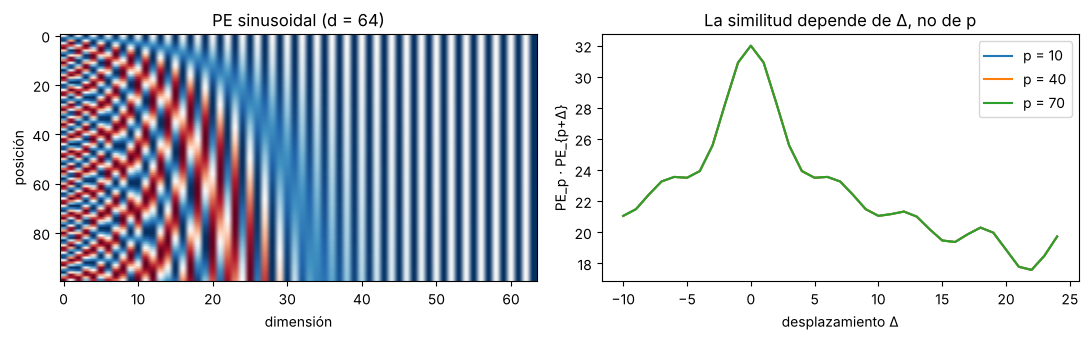

In [8]:
def pe_sinusoidal(n, d):
    pos = np.arange(n)[:, None]
    i = np.arange(0, d, 2)[None, :]
    pe = np.zeros((n, d))
    pe[:, 0::2] = np.sin(pos / 10000 ** (i / d))
    pe[:, 1::2] = np.cos(pos / 10000 ** (i / d))
    return pe

P = pe_sinusoidal(100, 64)
fig, axs = plt.subplots(1, 2, figsize=(11, 3.5))
axs[0].imshow(P, aspect="auto", cmap="RdBu"); axs[0].set_xlabel("dimensión"); axs[0].set_ylabel("posición")
axs[0].set_title("PE sinusoidal (d = 64)")
for p in [10, 40, 70]:
    axs[1].plot(range(-10, 25), [P[p] @ P[p + D] for D in range(-10, 25)], label=f"p = {p}")
axs[1].set_xlabel("desplazamiento Δ"); axs[1].set_ylabel("PE_p · PE_{p+Δ}"); axs[1].legend()
axs[1].set_title("La similitud depende de Δ, no de p")
plt.tight_layout(); plt.show()

**Análisis crítico:** si se omite la codificación posicional, demuestre (con la sección 2) que permutar las filas de $X$ solo permuta las filas de $Z$. ¿Qué significa eso para «perro muerde hombre» vs. «hombre muerde perro»?

In [9]:
perm = [2, 0, 1]
Zp, _, _ = self_attention(X[perm], WQ, WK, WV)
print("Z permutada == permutación de Z:", np.allclose(Zp, Z[perm]))

Z permutada == permutación de Z: True


## 5. Máscaras causal y de padding (tópico 07)
La máscara suma $-\infty$ a los scores prohibidos antes del softmax.

✍️ **Predicción:** en un decoder, si cambiamos el **último** token, ¿cambian las salidas de las posiciones anteriores?

In [10]:
def mascara_causal(n):
    return torch.triu(torch.full((n, n), float("-inf")), diagonal=1)

print(mascara_causal(5))

torch.manual_seed(0)
mha = MiMHA(16, 2)
x = torch.randn(1, 5, 16)
x_mod = x.clone(); x_mod[0, -1] = torch.randn(16)        # cambiar solo el último token

y_c, _ = mha(x, mascara_causal(5)); y_c2, _ = mha(x_mod, mascara_causal(5))
y_b, _ = mha(x);                    y_b2, _ = mha(x_mod)
print("Causal: posiciones 0-3 iguales?       ", torch.allclose(y_c[0, :4], y_c2[0, :4], atol=1e-6))
print("Bidireccional: posiciones 0-3 iguales?", torch.allclose(y_b[0, :4], y_b2[0, :4], atol=1e-6))

tensor([[0., -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0.]])
Causal: posiciones 0-3 iguales?        True
Bidireccional: posiciones 0-3 iguales? False


In [11]:
# Padding: lote con dos oraciones de longitud 5 y 3 (las 2 últimas posiciones son [PAD])
longitudes = torch.tensor([5, 3])
pad = torch.arange(5)[None, :] >= longitudes[:, None]          # True donde hay PAD
mask_pad = torch.zeros(2, 1, 1, 5).masked_fill(pad[:, None, None, :], float("-inf"))
_, alpha = mha(torch.randn(2, 5, 16), mask_pad)
print("Atención de la oración 2 (cabeza 0):\n", alpha[1, 0].detach().numpy().round(2))

Atención de la oración 2 (cabeza 0):
 [[0.09 0.8  0.11 0.   0.  ]
 [0.44 0.2  0.36 0.   0.  ]
 [0.36 0.26 0.38 0.   0.  ]
 [0.27 0.39 0.34 0.   0.  ]
 [0.29 0.44 0.28 0.   0.  ]]


**Análisis crítico:** ¿por qué la máscara causal permite entrenar todas las posiciones en paralelo y aun así respetar la factorización $p(x_1\dots x_n)=\prod_i p(x_i\mid x_{<i})$?

## 6. Bloque Transformer pre-norm y un mini modelo de lenguaje (tópicos 06 y 08)
Ecuaciones J&M 7.27–7.32: $t^1=\mathrm{LN}(x)$, $t^3=x+\mathrm{MHA}(t^1)$, $h=t^3+\mathrm{FFN}(\mathrm{LN}(t^3))$.
Entrenamos un decoder de caracteres muy pequeño sobre un texto en español para ver la pérdida de entropía cruzada y la perplejidad.

In [12]:
class Bloque(nn.Module):
    def __init__(self, d, A, p=0.1):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.att = MiMHA(d, A)
        self.ffn = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))
        self.drop = nn.Dropout(p)

    def forward(self, x, mask):
        a, _ = self.att(self.ln1(x), mask)
        x = x + self.drop(a)                       # residual 1
        return x + self.drop(self.ffn(self.ln2(x)))  # residual 2

class MiniLM(nn.Module):
    def __init__(self, V, d=64, A=4, L=2, n_max=64):
        super().__init__()
        self.E = nn.Embedding(V, d)
        self.P = nn.Embedding(n_max, d)            # posición aprendida
        self.bloques = nn.ModuleList([Bloque(d, A) for _ in range(L)])
        self.ln_f = nn.LayerNorm(d)
        self.n_max = n_max
        nn.init.normal_(self.E.weight, std=0.02); nn.init.normal_(self.P.weight, std=0.02)  # init estándar (GPT-2)

    def forward(self, ids):
        B, n = ids.shape
        x = self.E(ids) + self.P(torch.arange(n))
        mask = mascara_causal(n)
        for b in self.bloques:
            x = b(x, mask)
        return self.ln_f(x) @ self.E.weight.T      # weight tying: U = E

texto = ("""El procesamiento de lenguaje natural estudia cómo las máquinas leen, representan y generan lenguaje.
Los transformadores usan atención para que cada palabra consulte a las demás palabras de la oración.
La atención calcula similitudes entre consultas y claves, normaliza con softmax y combina los valores.
Un modelo de lenguaje predice el siguiente token a partir de los tokens anteriores.
""" * 30)
chars = sorted(set(texto)); V = len(chars)
stoi = {c: i for i, c in enumerate(chars)}; itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in texto])
corte = int(0.9 * len(data)); train, val = data[:corte], data[corte:]

def lote(split, B=32, n=64):
    src = train if split == "train" else val
    ix = torch.randint(len(src) - n - 1, (B,))
    return torch.stack([src[i:i+n] for i in ix]), torch.stack([src[i+1:i+n+1] for i in ix])

torch.manual_seed(SEED)
lm = MiniLM(V)
print("vocabulario:", V, "| parámetros:", sum(p.numel() for p in lm.parameters()))

vocabulario: 33 | parámetros: 106304


In [13]:
opt = torch.optim.AdamW(lm.parameters(), lr=3e-3)
hist = []
for paso in range(401):
    xb, yb = lote("train")
    logits = lm(xb)
    loss = F.cross_entropy(logits.reshape(-1, V), yb.reshape(-1))   # teacher forcing
    opt.zero_grad(); loss.backward(); opt.step()
    if paso % 50 == 0:
        lm.eval()
        with torch.no_grad():
            xv, yv = lote("val")
            lv = F.cross_entropy(lm(xv).reshape(-1, V), yv.reshape(-1)).item()
        lm.train()
        hist.append((paso, loss.item(), lv))
        print(f"paso {paso:3d}  CE train {loss.item():.3f}  CE val {lv:.3f}  PPL val {math.exp(lv):6.2f}")

paso   0  CE train 3.536  CE val 3.340  PPL val  28.21


paso  50  CE train 2.248  CE val 2.243  PPL val   9.42


paso 100  CE train 1.232  CE val 1.111  PPL val   3.04


paso 150  CE train 0.370  CE val 0.284  PPL val   1.33


paso 200  CE train 0.165  CE val 0.133  PPL val   1.14


paso 250  CE train 0.113  CE val 0.089  PPL val   1.09


paso 300  CE train 0.103  CE val 0.084  PPL val   1.09


paso 350  CE train 0.082  CE val 0.062  PPL val   1.06


paso 400  CE train 0.082  CE val 0.076  PPL val   1.08


**Análisis crítico**
1. La perplejidad inicial debería ser cercana a $V$ (modelo uniforme). ¿Se cumple? ¿Por qué?
2. El texto se repite 30 veces: ¿qué significa una perplejidad de validación muy baja en este caso? (memorización vs. generalización).
3. Elimine `self.P` (sin posición). ¿Qué ocurre con la pérdida? Explique.

## 7. Decodificación (tópico 08)
Primero verificamos el ejemplo de J&M (Fig. 7.21): logits $[1.2, 0.9, 0.1, -0.5]$ para *all, the, your, that*.

In [14]:
logits = torch.tensor([1.2, 0.9, 0.1, -0.5]); vocab4 = ["all", "the", "your", "that"]
for tau in [1.0, 0.5, 0.1, 10.0]:
    print(f"τ = {tau:4}:", (logits / tau).softmax(-1).numpy().round(3))

def top_k_filtrar(logits, k):
    v, _ = torch.topk(logits, k)
    return logits.masked_fill(logits < v[..., -1, None], float("-inf"))

def top_p_filtrar(logits, p):
    probs, idx = logits.softmax(-1).sort(descending=True)
    acum = probs.cumsum(-1)
    quitar = acum - probs >= p                 # conservar el menor conjunto con Σ ≥ p
    filtrado = logits.clone()
    filtrado[idx[quitar]] = float("-inf")
    return filtrado

print("top-k=2 :", top_k_filtrar(logits, 2).softmax(-1).numpy().round(3))
print("top-p=0.9:", top_p_filtrar(logits, 0.9).softmax(-1).numpy().round(3))

τ =  1.0: [0.443 0.328 0.148 0.081]
τ =  0.5: [0.591 0.324 0.065 0.02 ]
τ =  0.1: [0.953 0.047 0.    0.   ]
τ = 10.0: [0.27  0.262 0.241 0.227]
top-k=2 : [0.574 0.426 0.    0.   ]


top-p=0.9: [0.482 0.357 0.161 0.   ]


In [15]:
@torch.no_grad()
def generar(modelo, prefijo, n=120, tau=1.0, k=None, p=None, greedy=False):
    modelo.eval()
    ids = torch.tensor([[stoi[c] for c in prefijo]])
    for _ in range(n):
        u = modelo(ids[:, -modelo.n_max:])[0, -1]
        if greedy:
            nxt = u.argmax()
        else:
            u = u / tau
            if k: u = top_k_filtrar(u, k)
            if p: u = top_p_filtrar(u, p)
            nxt = torch.multinomial(u.softmax(-1), 1)[0]
        ids = torch.cat([ids, nxt.view(1, 1)], dim=1)
    return "".join(itos[i] for i in ids[0].tolist())

torch.manual_seed(1)
for cfg in [dict(greedy=True), dict(tau=0.5), dict(tau=1.5), dict(tau=1.0, k=5), dict(tau=1.0, p=0.9)]:
    print(cfg, "->", repr(generar(lm, "La atención ", 80, **cfg)))

{'greedy': True} -> 'La atención calcula similitudes entre consultas y claves, normaliza con softmax y combina lo'
{'tau': 0.5} -> 'La atención calcula similitudes entre consultas y claves, normaliza con softmax y combina lo'


{'tau': 1.5} -> 'La atención calcula similitudes entre consultas y claves, normaliza con softla ltes valores.'
{'tau': 1.0, 'k': 5} -> 'La atención calcula similitudes entre consultas y claves, normaliza con softmax y combina lo'


{'tau': 1.0, 'p': 0.9} -> 'La atención calcula similitudes entre consultas y claves, normaliza con softmax y combina lo'


**Análisis crítico:** relacione lo observado con la afirmación de J&M: *greedy es demasiado aburrido y el muestreo puro demasiado aleatorio*. ¿Qué configuración usaría para extracción de información y cuál para escritura creativa?

## 8. BETO: fill-mask y embeddings contextuales (tópicos 09 y 10)
**Requiere internet** para descargar `dccuchile/bert-base-spanish-wwm-cased` (Cañete et al., 2020). Si no hay conexión, la celda informa y continúa.

✍️ **Predicción:** ¿la similitud coseno entre «banco» (finanzas) y «banco» (finanzas) será mayor que entre «banco» (finanzas) y «banco» (parque)?

In [ ]:
from transformers import pipeline, AutoTokenizer, AutoModel
BETO = "dccuchile/bert-base-spanish-wwm-cased"
try:
    fill = pipeline("fill-mask", model=BETO)
    for frase in ["Fui al [MASK] a pedir un préstamo.", "Me senté en un [MASK] del parque."]:
        print(frase, [(r["token_str"], round(r["score"], 3)) for r in fill(frase)[:5]])
    HF_OK = True
except Exception as e:
    HF_OK = False
    print("No fue posible descargar el modelo (¿sin internet?):", type(e).__name__)

In [ ]:
if HF_OK:
    tok = AutoTokenizer.from_pretrained(BETO)
    enc = AutoModel.from_pretrained(BETO, output_hidden_states=True).eval()

    def vector_palabra(frase, palabra="banco", ultimas=4):
        b = tok(frase, return_tensors="pt")
        with torch.no_grad():
            hs = enc(**b).hidden_states                  # (L+1) x (1, n, 768)
        H = torch.stack(hs[-ultimas:]).mean(0)[0]        # promedio de las 4 últimas capas (J&M §10.1)
        ids = b.input_ids[0].tolist()
        sub = tok(palabra, add_special_tokens=False).input_ids     # la palabra puede ser varias subpalabras
        for i in range(len(ids) - len(sub) + 1):
            if ids[i:i + len(sub)] == sub:
                return H[i:i + len(sub)].mean(0)                     # promedio de sus subpalabras
        raise ValueError(f"'{palabra}' no encontrada en: {frase}")

    frases = {"finanzas_1": "El banco subió las tasas de interés.",
              "finanzas_2": "Abrí una cuenta de ahorros en el banco.",
              "parque":     "Me senté en un banco del parque.",
              "río":        "El barco encalló en un banco de arena."}
    vec = {k: vector_palabra(v) for k, v in frases.items()}
    nombres = list(vec)
    M = torch.stack([vec[k] for k in nombres])
    sim = F.cosine_similarity(M[:, None], M[None, :], dim=-1)
    print("Similitud coseno entre ocurrencias de «banco»:")
    print("            " + " ".join(f"{n:>11s}" for n in nombres))
    for i, n in enumerate(nombres):
        print(f"{n:>11s} " + " ".join(f"{sim[i, j]:11.3f}" for j in range(len(nombres))))

**Análisis crítico**
1. ¿Se agrupan las dos ocurrencias financieras? Compare los valores absolutos: ¿por qué incluso los sentidos distintos tienen coseno alto? (anisotropía, Ethayarajh, 2019).
2. Repita usando solo la última capa (`ultimas=1`) y la capa 4. ¿Qué capa separa mejor los sentidos?
3. Con un embedding estático (word2vec), ¿cuál sería la matriz de similitud? Justifique.

## 9. LLM local abierto: zero-shot y NER en JSON (tópicos 13 y 15)
Usamos `Qwen/Qwen2.5-0.5B-Instruct`, un decoder pequeño con pesos abiertos que corre en CPU. **Requiere internet** la primera vez.
Decodificación **greedy** (`do_sample=False`) para tareas de extracción. El resultado de un modelo de 0.5B debe **validarse**, no aceptarse.

In [ ]:
LLM = "Qwen/Qwen2.5-0.5B-Instruct"
try:
    gen = pipeline("text-generation", model=LLM)
    LLM_OK = True
except Exception as e:
    LLM_OK = False
    print("No fue posible descargar el LLM:", type(e).__name__)

def preguntar(prompt, max_new_tokens=120):
    msgs = [{"role": "system", "content": "Eres un asistente preciso. Responde en español."},
            {"role": "user", "content": prompt}]
    out = gen(msgs, max_new_tokens=max_new_tokens, do_sample=False)
    return out[0]["generated_text"][-1]["content"].strip()

if LLM_OK:
    # Ver la plantilla de chat: la conversación es una sola secuencia de tokens (tópico 13)
    print(gen.tokenizer.apply_chat_template([{"role": "user", "content": "Hola"}], tokenize=False, add_generation_prompt=True))

In [ ]:
if LLM_OK:
    textos = ["El servicio del banco fue lento, pero el asesor resolvió todo.",
              "Excelente clase, por fin entendí la atención multi-cabeza.",
              "La plataforma se cayó otra vez durante el parcial."]
    for t in textos:
        r = preguntar("Clasifica el sentimiento como positivo, negativo o neutro. Responde solo con la etiqueta.\nTexto: " + t, 5)
        print(f"{r:10s} <- {t}")

In [ ]:
def extraer_json(respuesta):
    m = re.search(r"\{.*\}", respuesta, re.S)
    if not m:
        return None
    try:
        return json.loads(m.group(0))
    except json.JSONDecodeError:
        return None

if LLM_OK:
    texto = "Ana Ruiz presentó su tesis sobre PLN en la Fundación Lingua, en Cartagena."
    r = preguntar("Extrae personas, organizaciones y lugares del texto. Devuelve solo JSON con las claves PER, ORG y LOC (listas).\nTexto: " + texto)
    print("Respuesta cruda:\n", r)
    print("JSON válido:", extraer_json(r))

**Análisis crítico**
1. ¿El JSON fue válido en todos los casos? Proponga una métrica (p. ej., F1 por entidad) y un pequeño conjunto de prueba de 20 oraciones para evaluarlo contra un modelo BETO afinado para NER.
2. Cambie a `do_sample=True, temperature=1.2`. ¿Qué pasa con la validez del formato? Relacione con la sección 7.
3. Identifique un caso en español regional (Caribe colombiano) donde el modelo falle y explique la posible causa (datos, tokenización, tamaño).

---
### Entregable
Un informe breve (máx. 2 páginas) con: las predicciones ✍️ y los resultados reales, una figura propia, las respuestas a las preguntas de análisis crítico y un caso de falla documentado. En la sustentación oral se pedirá explicar una celda elegida por el docente.